# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   **Sumber Dataset saya**: Dataset yang digunakan pada proyek ini adalah Telco Customer Churn Dataset yang berisi informasi pelanggan layanan telekomunikasi, seperti jenis layanan internet, lama berlangganan (tenure), biaya bulanan, biaya total, metode pembayaran, serta status pelanggan apakah berhenti berlangganan (churn) atau tidak.Tujuan dari proyek ini adalah membangun model machine learning untuk memprediksi kemungkinan pelanggan berhenti menggunakan layanan perusahaan (customer churn prediction).
   
   Target pada dataset ini adalah kolom `Churn`:
   - Yes = pelanggan berhenti berlangganan
   - No = pelanggan tetap berlangganan
   
   Sumber dataset:
   Kaggle - Telco Customer Churn Dataset.
   Link Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Jumlah baris dan kolom:")
df.shape

Jumlah baris dan kolom:


(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
#Cek Missing Value
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Berdasarkan hasil pengecekan, tidak ditemukan missing value secara langsung. Namun, perlu dilakukan pemeriksaan lebih lanjut terhadap nilai kosong yang tersimpan sebagai string.

In [10]:
#Cek Nilai Kosong
(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Ditemukan nilai kosong pada kolom TotalCharges yang tersimpan dalam bentuk string kosong (" "). Nilai tersebut perlu ditangani pada tahap preprocessing.

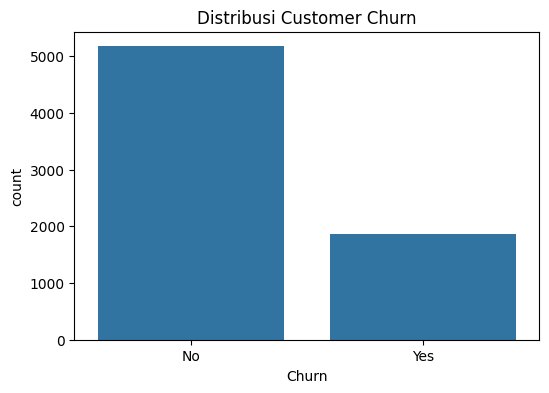

In [11]:
#Distribusi Target Churn
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Distribusi Customer Churn")
plt.show()

Mayoritas pelanggan tidak melakukan churn, namun terdapat sejumlah pelanggan yang berhenti berlangganan sehingga permasalahan churn layak untuk diprediksi menggunakan machine learning.

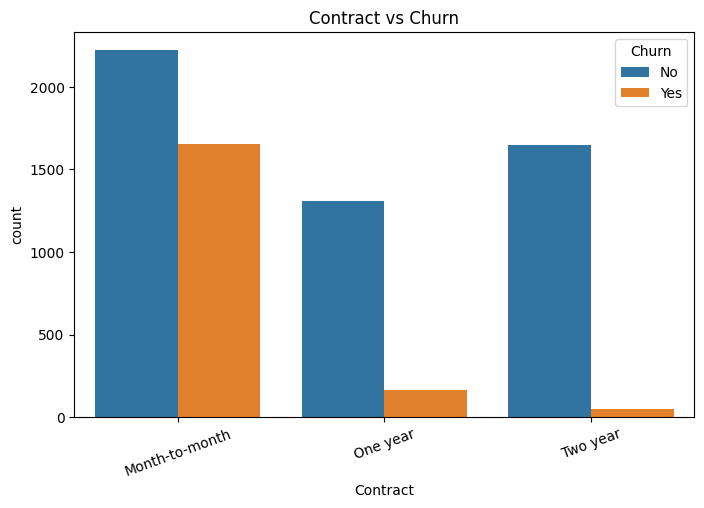

In [12]:
#Distribusi Contract
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.xticks(rotation=20)
plt.title("Contract vs Churn")
plt.show()

Pelanggan dengan kontrak month-to-month memiliki tingkat churn yang lebih tinggi dibandingkan pelanggan dengan kontrak satu tahun maupun dua tahun.

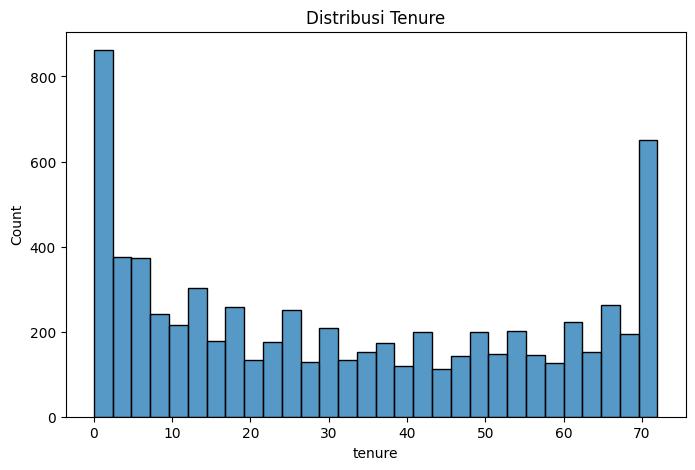

In [13]:
#Distribusi Tenure
plt.figure(figsize=(8,5))

sns.histplot(
    df['tenure'],
    bins=30
)

plt.title("Distribusi Tenure")
plt.show()

Distribusi tenure menunjukkan bahwa dataset berisi pelanggan baru maupun pelanggan lama sehingga memberikan variasi yang baik untuk proses pembelajaran model.

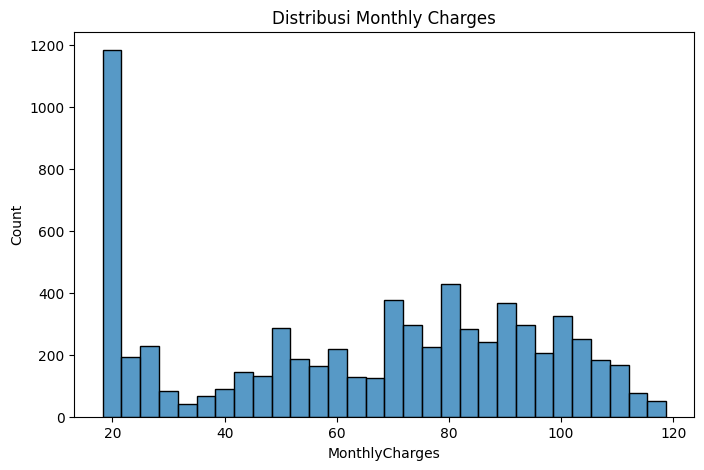

In [14]:
#Monthly Charges
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyCharges'],
    bins=30
)

plt.title("Distribusi Monthly Charges")
plt.show()

Biaya bulanan pelanggan bervariasi dengan rentang yang cukup luas, menunjukkan adanya perbedaan paket layanan yang digunakan pelanggan.

In [15]:
#Cek Duplikasi Data
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


Pengecekan dilakukan untuk memastikan tidak terdapat data yang tercatat lebih dari satu kali sehingga dapat memengaruhi hasil pelatihan model.

## Kesimpulan EDA

Berdasarkan hasil eksplorasi data:

- Dataset terdiri dari 7043 data pelanggan.
- Target churn memiliki dua kelas yaitu pelanggan yang churn dan tidak churn.
- Ditemukan nilai kosong pada kolom TotalCharges yang perlu ditangani.
- Kontrak month-to-month menunjukkan tingkat churn yang lebih tinggi dibandingkan kontrak jangka panjang.
- Dataset memiliki kombinasi fitur numerik dan kategorikal yang sesuai untuk membangun model klasifikasi.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [16]:
#Menghapus Kolom Tidak Relevan
df.drop(
    'customerID',
    axis=1,
    inplace=True
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Kolom customerID hanya berfungsi sebagai identitas unik pelanggan sehingga tidak memiliki kontribusi terhadap proses prediksi churn.

In [17]:
#Menangani Missing Value
df['TotalCharges'] = df['TotalCharges'].replace(
    ' ',
    np.nan
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges']
)

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

df.isnull().sum()

/tmp/ipykernel_1931/2186074912.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Nilai kosong pada kolom TotalCharges diganti menggunakan median untuk mempertahankan distribusi data dan menghindari kehilangan informasi akibat penghapusan baris.

In [18]:
#Menghapus Data Duplikat
print("Jumlah data sebelum:", df.shape)

df.drop_duplicates(inplace=True)

print("Jumlah data sesudah:", df.shape)

Jumlah data sebelum: (7043, 20)
Jumlah data sesudah: (7021, 20)


Data duplikat dihapus agar setiap observasi bersifat unik dan tidak menyebabkan bias pada model machine learning.

In [19]:
#Encoding Data Kategorikal
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


Encoding dilakukan untuk mengubah data kategorikal menjadi bentuk numerik sehingga dapat diproses oleh algoritma machine learning.

In [20]:
#Memisahkan Fitur dan Target
X = df.drop(
    'Churn',
    axis=1
)

y = df['Churn']

In [21]:
#Standardisasi Data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Standardisasi dilakukan agar seluruh fitur memiliki skala yang seragam dan tidak mendominasi proses pembelajaran model.

In [22]:
#Membuat Dataset Hasil Preprocessing
processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df['Churn'] = y

processed_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,-1.008726,-0.440508,1.031400,-0.655475,-1.282728,-3.048725,0.059614,-1.181531,-0.918456,1.240410,-1.027886,-0.924901,-1.113775,-1.121714,-0.830396,0.829057,0.402156,-1.164135,-0.997328,0.0
1,0.991349,-0.440508,-0.969556,-0.655475,0.062387,0.328006,-0.994674,-1.181531,1.405320,-1.029902,1.242972,-0.924901,-1.113775,-1.121714,0.368496,-1.206190,1.338965,-0.262811,-0.176347,0.0
2,0.991349,-0.440508,-0.969556,-0.655475,-1.241967,0.328006,-0.994674,-1.181531,1.405320,1.240410,-1.027886,-0.924901,-1.113775,-1.121714,-0.830396,0.829057,1.338965,-0.365914,-0.962760,1.0
3,0.991349,-0.440508,-0.969556,-0.655475,0.510759,-3.048725,0.059614,-1.181531,1.405320,-1.029902,1.242972,1.394288,-1.113775,-1.121714,0.368496,-1.206190,-1.471460,-0.750058,-0.197869,0.0
4,-1.008726,-0.440508,-0.969556,-0.655475,-1.241967,0.328006,-0.994674,0.175278,-0.918456,-1.029902,-1.027886,-0.924901,-1.113775,-1.121714,-0.830396,0.829057,0.402156,0.194503,-0.943556,1.0


In [23]:
#Menyimpan Dataset Hasil Preprocessing
processed_df.to_csv(
    'telco_churn_preprocessed.csv',
    index=False
)

In [24]:
print("Ukuran dataset hasil preprocessing:")
processed_df.shape

Ukuran dataset hasil preprocessing:


(7021, 20)

Dataset hasil preprocessing berhasil disimpan dan siap digunakan pada tahap pelatihan model machine learning.